In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('dataset_clean.csv')
df.head(5)

,no,variant_id,variant_nama,satuan_display,tanggal,harga,day,day_of_week,is_weekend,price_lag_1,price_lag_2,price_lag_3,rolling_mean_7d
0,0,2,Cabai Merah Keriting,kg,2026-01-04,45944.0,4,6,1,46609.0,47274.0,47274.0,46775.250000
1,1,2,Cabai Merah Keriting,kg,2026-01-05,45279.0,5,0,0,45944.0,46609.0,47274.0,46476.000000
2,2,2,Cabai Merah Keriting,kg,2026-01-06,44017.0,6,1,0,45279.0,45944.0,46609.0,46066.166667
3,3,2,Cabai Merah Keriting,kg,2026-01-07,42926.0,7,2,0,44017.0,45279.0,45944.0,45617.571429
4,4,2,Cabai Merah Keriting,kg,2026-01-08,42255.0,8,3,0,42926.0,44017.0,45279.0,44900.571429


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1648 entries, 0 to 1647
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   no               1648 non-null   int64  
 1   variant_id       1648 non-null   int64  
 2   variant_nama     1648 non-null   object 
 3   satuan_display   1648 non-null   object 
 4   tanggal          1648 non-null   object 
 5   harga            1648 non-null   float64
 6   day              1648 non-null   int64  
 7   day_of_week      1648 non-null   int64  
 8   is_weekend       1648 non-null   int64  
 9   price_lag_1      1648 non-null   float64
 10  price_lag_2      1648 non-null   float64
 11  price_lag_3      1648 non-null   float64
 12  rolling_mean_7d  1648 non-null   float64
dtypes: float64(5), int64(5), object(3)
memory usage: 167.5+ KB


In [8]:
df['harga'].isna().sum()

np.int64(0)

In [3]:

df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values(by=['variant_id', 'tanggal']).reset_index(drop=True)
df['harga'] = df['harga'].replace(0, np.nan)

Linear Interpolation (If some data have a value 0, get a value for this data [day x] of data day x-1 and data day x+1)

In [4]:
df['harga'] = df.groupby('variant_id')['harga'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

In [11]:
df.head(5)

,no,variant_id,variant_nama,satuan_display,tanggal,harga,day,day_of_week,is_weekend,price_lag_1,price_lag_2,price_lag_3,rolling_mean_7d
0,0,2,Cabai Merah Keriting,kg,2026-01-04,45944.0,4,6,1,46609.0,47274.0,47274.0,46775.250000
1,1,2,Cabai Merah Keriting,kg,2026-01-05,45279.0,5,0,0,45944.0,46609.0,47274.0,46476.000000
2,2,2,Cabai Merah Keriting,kg,2026-01-06,44017.0,6,1,0,45279.0,45944.0,46609.0,46066.166667
3,3,2,Cabai Merah Keriting,kg,2026-01-07,42926.0,7,2,0,44017.0,45279.0,45944.0,45617.571429
4,4,2,Cabai Merah Keriting,kg,2026-01-08,42255.0,8,3,0,42926.0,44017.0,45279.0,44900.571429


Exploratory Data Analysis (EDA)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14572\3853002565.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


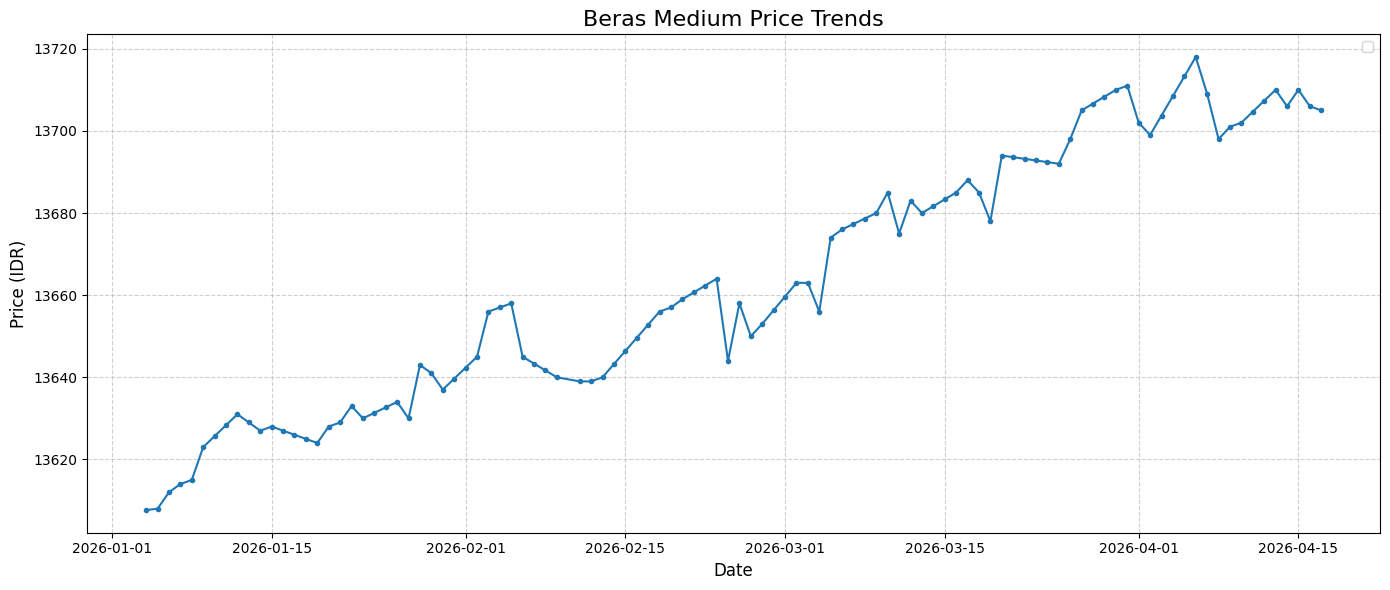

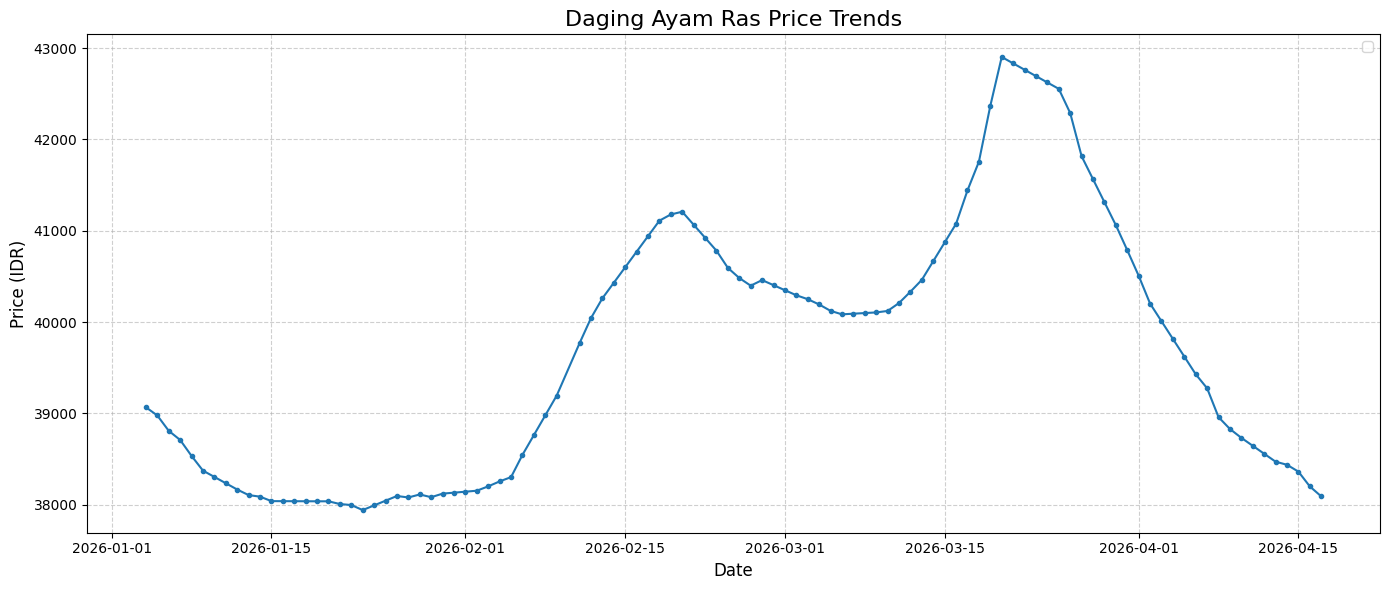

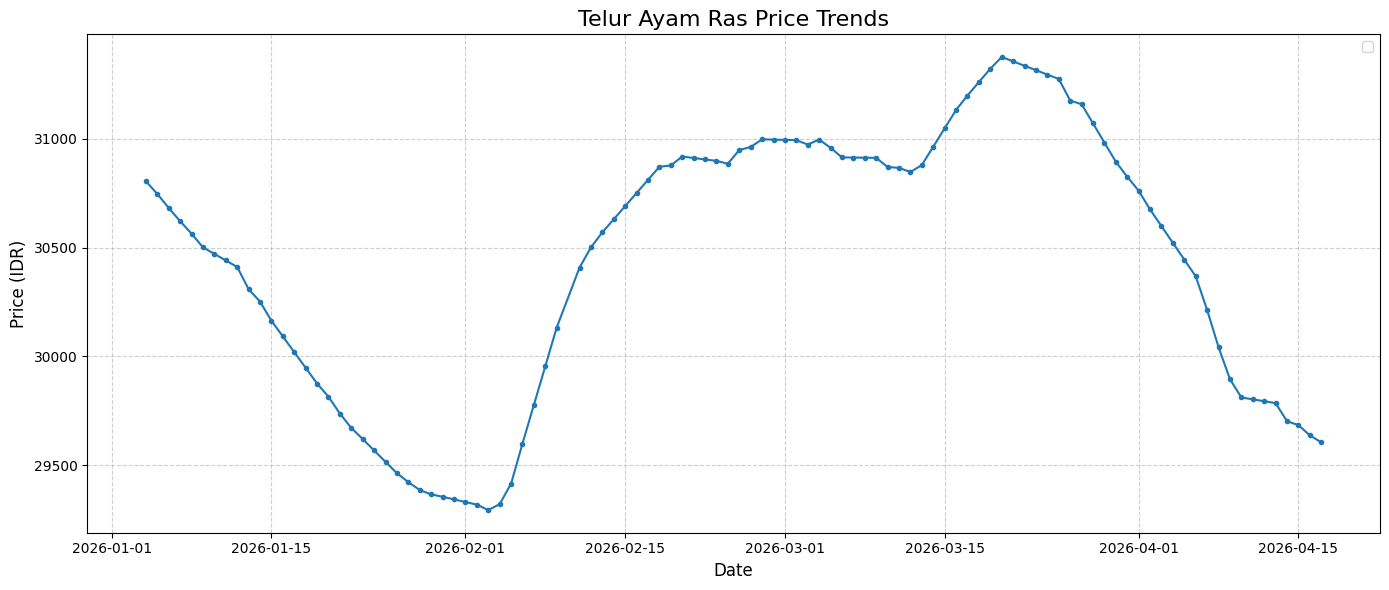

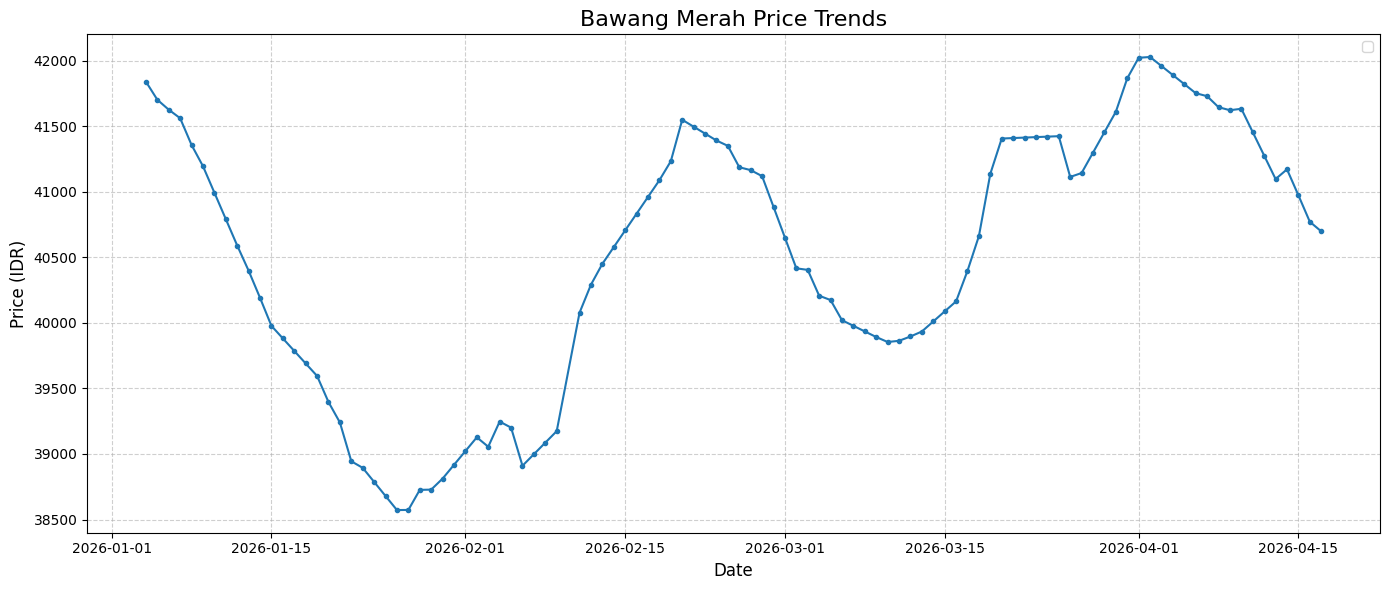

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_commodities = ['Beras Medium', 'Daging Ayam Ras', 'Telur Ayam Ras', 'Bawang Merah']

for commodity in sample_commodities:
    plt.figure(figsize=(14, 6))
    plot_data = df[df['variant_nama'] == commodity]
    plt.plot(plot_data['tanggal'], plot_data['harga'], marker='o', markersize=3)

    plt.title(f'{commodity} Price Trends', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (IDR)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


Featured Engineering

Stationarity Test (ADF - Augmented Dickey-Fuller)

In [ ]:
# from statsmodels.tsa.stattools import adfuller
# import pandas as pd

# def perform_adf_test(timeseries, name):
#     result = adfuller(timeseries.dropna(), autolag='AIC')
    
#     print(f'ADF Test Results untuk {name}:')
#     print(f'ADF Statistic: {result[0]:.6f}')
#     print(f'P-value: {result[1]:.6f}')
#     print(f'Critical Values:')
#     for key, value in result[4].items():
#         print(f'  {key}: {value:.3f}')
    
#     # Kesimpulan
#     if result[1] <= 0.05:
#         print(f"✓ {name} adalah STATIONARY (p-value = {result[1]:.6f})")
#         return True
#     else:
#         print(f"✗ {name} adalah NON-STATIONARY (p-value = {result[1]:.6f})")
#         return False

# # Test stasioneritas untuk setiap komoditas
# print("="*70)
# print("TESTING STASIONERITAS DATA HARGA")
# print("="*70)

# adf_results = {}
# for commodity in df['variant_nama'].unique():
#     commodity_data = df[df['variant_nama'] == commodity]['harga']
#     is_stationary = perform_adf_test(commodity_data, commodity)
#     adf_results[commodity] = {
#         'stationary': is_stationary,
#         'adf_stat': adfuller(commodity_data.dropna(), autolag='AIC')[0],
#         'p_value': adfuller(commodity_data.dropna(), autolag='AIC')[1]
#     }
#     print("-"*70)

# # Summary dalam bentuk tabel
# adf_df = pd.DataFrame([
#     {
#         'Komoditas': commodity,
#         'Stationary': results['stationary'],
#         'ADF Statistic': results['adf_stat'],
#         'P-value': results['p_value']
#     }
#     for commodity, results in adf_results.items()
# ])

# print("\nRINGKASAN HASIL ADF TEST:")
# print(adf_df.to_string(index=False))

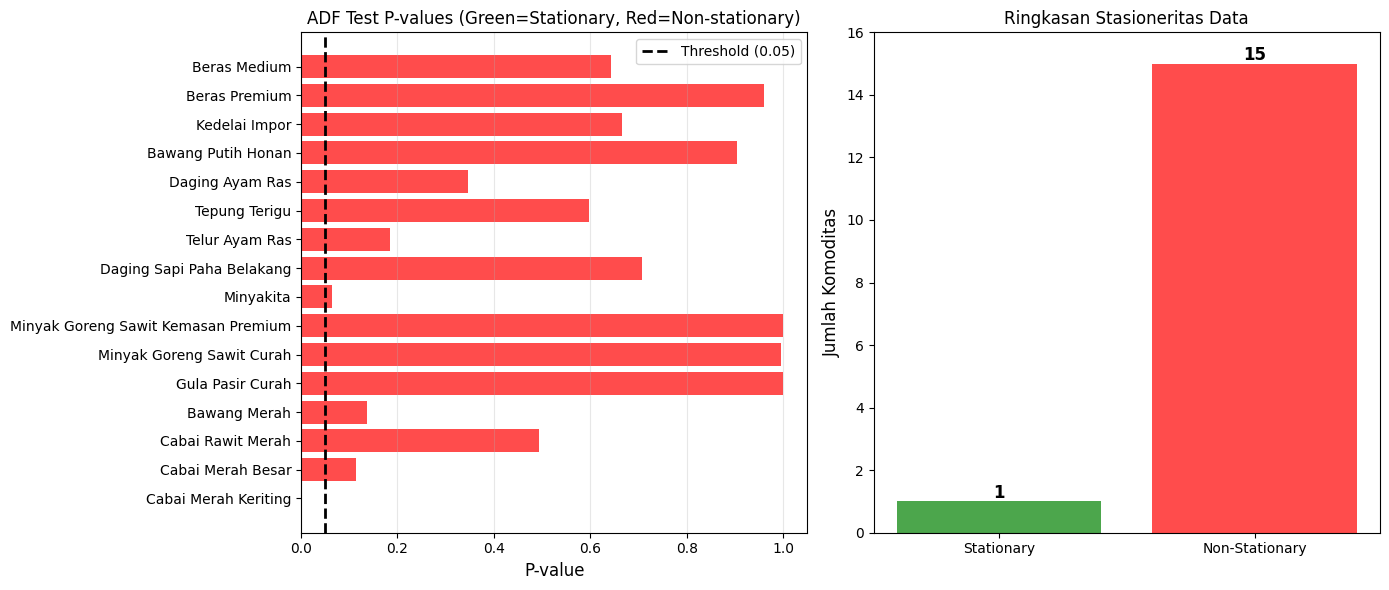


Summary: 1 komoditas STATIONARY, 15 komoditas NON-STATIONARY


In [6]:
# Visualisasi hasil ADF test
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: P-values untuk setiap komoditas
commodities_list = list(adf_results.keys())
p_values = [adf_results[c]['p_value'] for c in commodities_list]
colors = ['green' if p <= 0.05 else 'red' for p in p_values]

axes[0].barh(commodities_list, p_values, color=colors, alpha=0.7)
axes[0].axvline(x=0.05, color='black', linestyle='--', linewidth=2, label='Threshold (0.05)')
axes[0].set_xlabel('P-value', fontsize=12)
axes[0].set_title('ADF Test P-values (Green=Stationary, Red=Non-stationary)', fontsize=12)
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Chart 2: Ringkasan jumlah data stationary vs non-stationary
stationary_count = sum(1 for r in adf_results.values() if r['stationary'])
non_stationary_count = len(adf_results) - stationary_count

categories = ['Stationary', 'Non-Stationary']
counts = [stationary_count, non_stationary_count]
colors_summary = ['green', 'red']

axes[1].bar(categories, counts, color=colors_summary, alpha=0.7)
axes[1].set_ylabel('Jumlah Komoditas', fontsize=12)
axes[1].set_title('Ringkasan Stasioneritas Data', fontsize=12)
axes[1].set_ylim(0, max(counts) + 1)

# Tambah nilai di atas bar
for i, (cat, count) in enumerate(zip(categories, counts)):
    axes[1].text(i, count + 0.1, str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSummary: {stationary_count} komoditas STATIONARY, {non_stationary_count} komoditas NON-STATIONARY")

In [13]:
df['day'] = df['tanggal'].dt.day
df['day_of_week'] = df['tanggal'].dt.dayofweek # 0=Monday, 6=Sunday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Lag Features
# Grouping by 'variant_id' prevents data leakage between different commodities
df['price_lag_1'] = df.groupby('variant_id')['harga'].shift(1)
df['price_lag_2'] = df.groupby('variant_id')['harga'].shift(2)
df['price_lag_3'] = df.groupby('variant_id')['harga'].shift(3)

# Rolling Statistics
# Calculate 7-day moving average to capture short-term trends
df['rolling_mean_7d'] = df.groupby('variant_id')['harga'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

In [14]:
df_fe = df.dropna().reset_index(drop=True)

In [15]:
df_fe.to_csv('dataset_transformed.csv')